In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\subas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df=pd.read_csv("C:\\24EG107F25\\projects\\flipkart review sentiment analysis\\flipkartsentiment.csv",on_bad_lines='skip')

In [5]:
df.sample(5)

,product_name,product_price,Rate,Review,Summary,Sentiment
52576,"Pack of 2 Solid Men Black, Blue Casual Shorts",319,5,NaN,love it,positive
74372,NIVIA Storm Football - Size: 5ÐÓ®ÐÂ ÐÓ®ÐÂ ...,429,2,moderate,very very bad,negative
143543,Bhimada cloth stand rack shelf almirah PVC Col...,700,5,just wow!,very nice,positive
28885,Lakm?? Eyeconic Kajal Twin Pack??????(Deep Bla...,218,4,good quality product,good,positive
187049,Men Regular Fit Black Cotton Blend Trousers,409,2,not specified,fabric is not good,negative


In [6]:
print(df.columns)

Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')


In [7]:
print(df.isnull().sum())

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64


In [8]:
print(df.shape)

(205052, 6)


In [9]:
df=df[['Review','Sentiment']]
df.dropna(inplace=True)
print(df.shape)

(180388, 2)


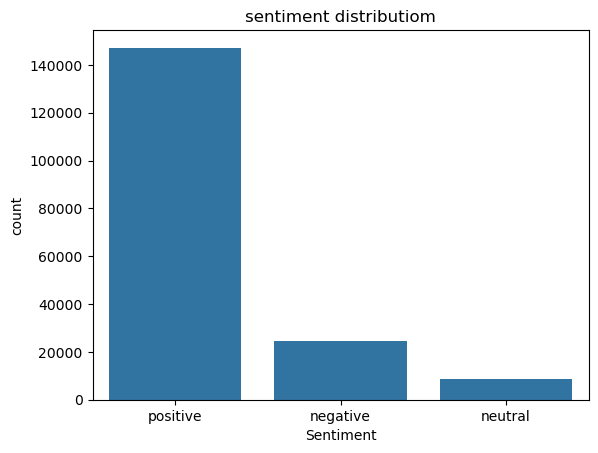

In [10]:
sns.countplot(x='Sentiment',data=df)
plt.title("sentiment distributiom")
plt.show()

In [11]:
stop_words=set(stopwords.words('english'))
stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('nor')
def clean_text(text):
  text=text.lower()
  text=re.sub(r'\d+','',text) #remove numbers
  text=text.translate(str.maketrans('','',string.punctuation))
  text=text.strip()
  words=text.split()
  words=[i for i in words if i not in stop_words]
  return " ".join(words)


In [12]:
df['cleaned_review']=df['Review'].apply(clean_text)


In [13]:
print(df[['Review','cleaned_review']].sample(5))

                        Review   cleaned_review
66526                excellent        excellent
22004                     nice             nice
197899               brilliant        brilliant
142700  not recommended at all  not recommended
90141          worth the money      worth money


In [14]:
tfidf=TfidfVectorizer(max_features=5000)
x=tfidf.fit_transform(df['cleaned_review'])

In [15]:
y=df['Sentiment']

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
model= LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(x_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_pred=model.predict(x_test)

In [21]:
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

accuracy: 0.8140972337712733


In [22]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.84      0.78      0.81      4735
     neutral       0.13      0.43      0.20      1761
    positive       0.96      0.84      0.90     29582

    accuracy                           0.81     36078
   macro avg       0.64      0.69      0.64     36078
weighted avg       0.91      0.81      0.85     36078



In [23]:
matrix=confusion_matrix(y_test,y_pred)
print(matrix)

[[ 3706   760   269]
 [  359   758   644]
 [  363  4312 24907]]


<Axes: >

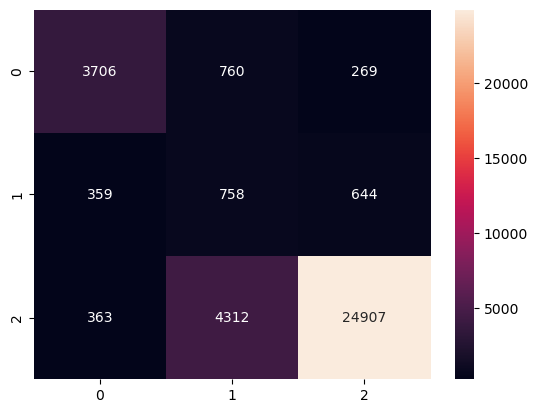

In [24]:
sns.heatmap(matrix,annot=True,fmt='d')


In [25]:
import pickle
pickle.dump(model,open('model.pkl','wb'))
pickle.dump(tfidf,open('tfidf.pkl','wb'))
